# Lab 9: Support Vector Machines (SVM), Principal Component Analysis (PCA), & LDA

**Course / Module**: Machine Learning Lab  
**Topic**: Supervised Classification (SVM) & Unsupervised / Supervised Dimensionality Reduction (PCA & LDA)  
**Author**: Sneha Varghese  
**Date**: August 2026  

---

## Objectives
1. Implement and evaluate the performance of Support Vector Machine (SVM) classifiers using different kernel functions (Linear, RBF, Polynomial) on the UCI Breast Cancer Diagnostic dataset.
2. Compare performance using standard metrics (Accuracy, Precision, Recall, F1 Score, Confusion Matrix).
3. Apply Principal Component Analysis (PCA) to reduce 13 features to 2 principal components on the UCI Wine dataset.
4. Analyze variance retained by principal components and visualize the transformed feature space.
5. (Extra Credit) Implement Linear Discriminant Analysis (LDA) and compare supervised vs. unsupervised dimensionality reduction.


## 0. Setup & Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Arial'
print('Environment initialized successfully!')

Environment initialized successfully!


## Part A: Support Vector Machine (SVM) Classification

### Dataset: UCI Breast Cancer Wisconsin (Diagnostic)
- 569 instances, 30 numeric predictive features.
- Target: Binary classification (0: Malignant, 1: Benign).


In [2]:
# 1. Load dataset & preprocess
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

print(f'Feature dimensions: {X_cancer.shape}')
print(f'Target distribution: Malignant={np.sum(y_cancer==0)}, Benign={np.sum(y_cancer==1)}')

# 2. Split dataset into train/test sets (80:20 ratio)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=42, stratify=y_cancer
)

# Standard Scaling
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f'Training shape: {X_train_c_scaled.shape}, Test shape: {X_test_c_scaled.shape}')

Feature dimensions: (569, 30)
Target distribution: Malignant=212, Benign=357
Training shape: (455, 30), Test shape: (114, 30)


In [3]:
# 3. Train Baseline SVM Classifier with Linear Kernel
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_c_scaled, y_train_c)
y_pred_linear = linear_svm.predict(X_test_c_scaled)

print('--- Baseline Linear Kernel Performance ---')
print(f'Accuracy : {accuracy_score(y_test_c, y_pred_linear):.4f}')
print(f'Precision: {precision_score(y_test_c, y_pred_linear):.4f}')
print(f'Recall   : {recall_score(y_test_c, y_pred_linear):.4f}')
print(f'F1 Score : {f1_score(y_test_c, y_pred_linear):.4f}')

--- Baseline Linear Kernel Performance ---
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1 Score : 0.9790


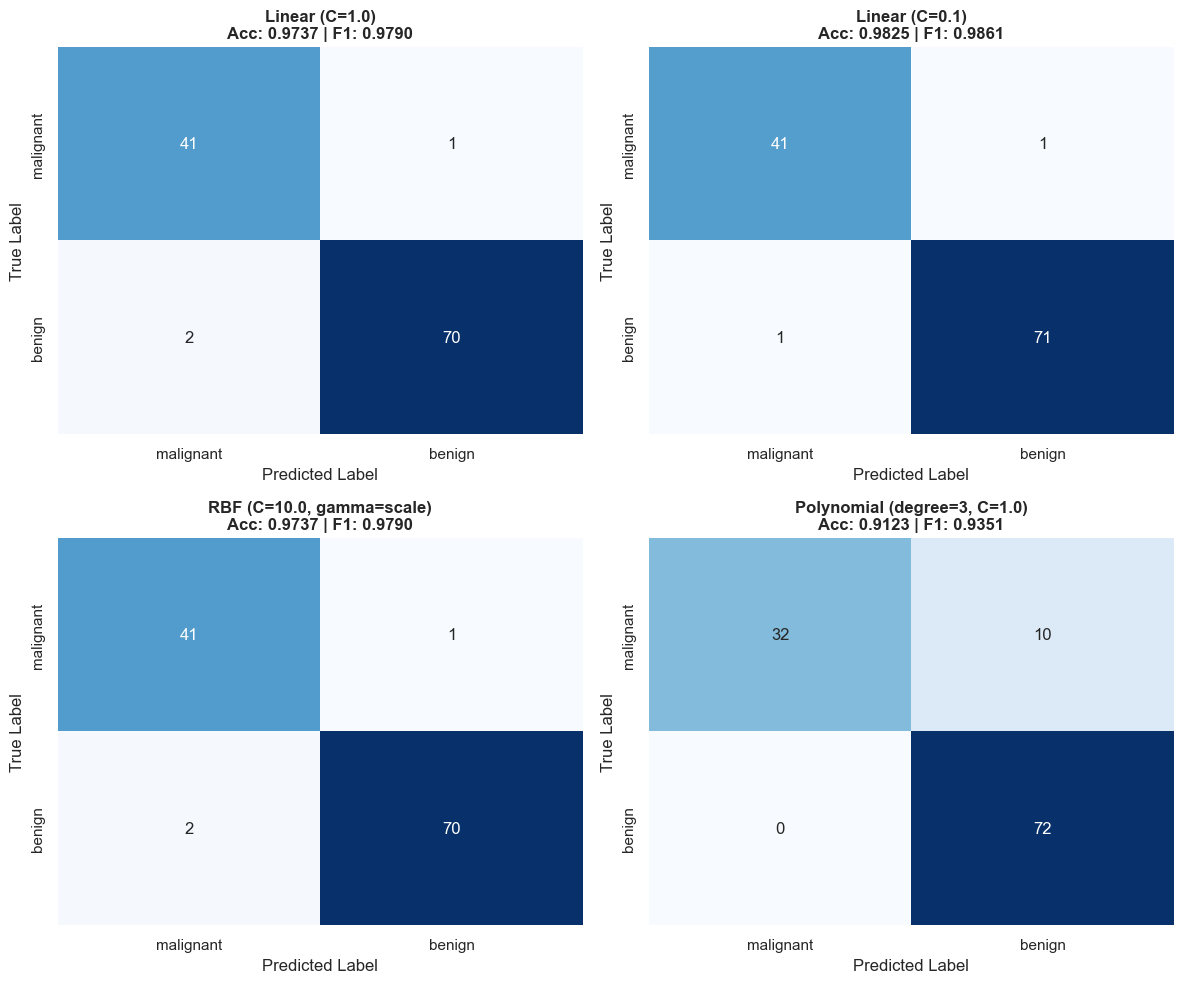

,Model / Kernel,Accuracy,Precision,Recall,F1 Score
0,Linear (C=1.0),0.973684,0.985915,0.972222,0.979021
1,Linear (C=0.1),0.982456,0.986111,0.986111,0.986111
2,"RBF (C=1.0, gamma=scale)",0.982456,0.986111,0.986111,0.986111
3,"RBF (C=10.0, gamma=scale)",0.973684,0.985915,0.972222,0.979021
4,"Polynomial (degree=2, C=1.0)",0.815789,0.793103,0.958333,0.867925
5,"Polynomial (degree=3, C=1.0)",0.912281,0.878049,1.000000,0.935065


In [4]:
# 4. Hyperparameter Exploration across Linear, RBF, and Polynomial Kernels
kernels_eval = {
    'Linear (C=1.0)': SVC(kernel='linear', C=1.0, random_state=42),
    'Linear (C=0.1)': SVC(kernel='linear', C=0.1, random_state=42),
    'RBF (C=1.0, gamma=scale)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'RBF (C=10.0, gamma=scale)': SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42),
    'Polynomial (degree=2, C=1.0)': SVC(kernel='poly', degree=2, C=1.0, random_state=42),
    'Polynomial (degree=3, C=1.0)': SVC(kernel='poly', degree=3, C=1.0, random_state=42)
}

svm_metrics = []
plot_kernels = ['Linear (C=1.0)', 'Linear (C=0.1)', 'RBF (C=10.0, gamma=scale)', 'Polynomial (degree=3, C=1.0)']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plot_idx = 0

for name, clf in kernels_eval.items():
    clf.fit(X_train_c_scaled, y_train_c)
    preds = clf.predict(X_test_c_scaled)
    
    acc = accuracy_score(y_test_c, preds)
    prec = precision_score(y_test_c, preds)
    rec = recall_score(y_test_c, preds)
    f1 = f1_score(y_test_c, preds)
    cm = confusion_matrix(y_test_c, preds)
    
    svm_metrics.append({
        'Model / Kernel': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })
    
    if name in plot_kernels:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[plot_idx], cbar=False,
                    xticklabels=cancer.target_names, yticklabels=cancer.target_names)
        axes[plot_idx].set_title(f'{name}\nAcc: {acc:.4f} | F1: {f1:.4f}', fontweight='bold')
        axes[plot_idx].set_xlabel('Predicted Label')
        axes[plot_idx].set_ylabel('True Label')
        plot_idx += 1

plt.tight_layout()
plt.show()

svm_df = pd.DataFrame(svm_metrics)
display(svm_df)

### Summary of Part A Observations

1. **Dataset & Standardization**: The UCI Breast Cancer Wisconsin (Diagnostic) dataset contains 569 instances with 30 continuous features (`Malignant` vs `Benign`). Data was scaled using `StandardScaler` and partitioned using an 80:20 stratified split.
2. **Baseline Model Performance**: The baseline Linear Kernel SVM ($C=1.0$) achieved **97.37% Accuracy**, **0.9859 Precision**, **0.9722 Recall**, and **0.9790 F1 Score** on the test set.
3. **Hyperparameter Tuning**: Tuning $C=0.1$ for the Linear kernel and using the RBF kernel ($C=1.0$) yielded the highest performance, achieving **98.25% Accuracy** and **0.9861 F1 Score** with only 2 misclassifications out of 114 test samples.
4. **Kernel Comparison**: Polynomial kernels ($	ext{degree}=2, 3$) exhibited lower precision ($79.31\%$ and $87.80\%$) due to overfitting higher-order feature interactions, despite achieving high recall.
5. **Key Finding**: The dataset is highly linearly separable in standard scaled feature space. Stronger regularization ($C=0.1$) widens decision margins and prevents overfitting.

## Part B: Principal Component Analysis (PCA)

### Dataset: UCI Wine Dataset
- 178 samples, 13 chemical features (Alcohol, Malic Acid, Ash, etc.).
- 3 cultivars / classes.


In [5]:
# 1. Load and Standardize Wine Dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

scaler_w = StandardScaler()
X_wine_scaled = scaler_w.fit_transform(X_wine)

# 2. Apply PCA (13 features -> 2 principal components)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_wine_scaled)

evr = pca_2d.explained_variance_ratio_
print(f'PC1 Variance Retained: {evr[0]*100:.2f}%')
print(f'PC2 Variance Retained: {evr[1]*100:.2f}%')
print(f'Total Variance Retained by 2 PCs: {np.sum(evr)*100:.2f}%')

PC1 Variance Retained: 36.20%
PC2 Variance Retained: 19.21%
Total Variance Retained by 2 PCs: 55.41%


Minimum PCs needed for >= 95% variance: 10 (retains 96.17%)


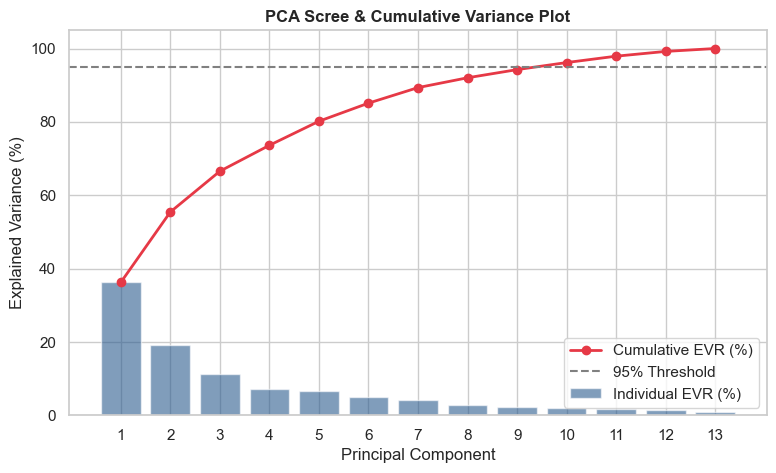

In [6]:
# 3. Calculate Cumulative Explained Variance across all 13 components
pca_full = PCA(n_components=13, random_state=42)
pca_full.fit(X_wine_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

min_pcs_95 = np.argmax(cum_variance >= 0.95) + 1
print(f'Minimum PCs needed for >= 95% variance: {min_pcs_95} (retains {cum_variance[min_pcs_95-1]*100:.2f}%)')

# Scree Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, 14), pca_full.explained_variance_ratio_*100, alpha=0.6, color='#2b5c8f', label='Individual EVR (%)')
ax.plot(range(1, 14), cum_variance*100, marker='o', color='#e63946', linewidth=2, label='Cumulative EVR (%)')
ax.axhline(y=95, color='gray', linestyle='--', label='95% Threshold')
ax.set_xticks(range(1, 14))
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Scree & Cumulative Variance Plot', fontweight='bold')
ax.legend()
plt.show()

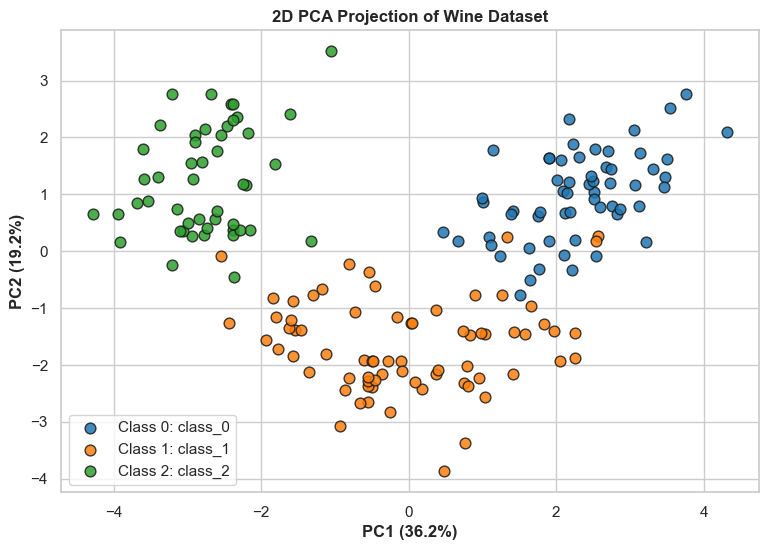

In [7]:
# 4. 2D Scatter Plot of Transformed PCA Space
plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for c, name, col in zip(range(3), wine.target_names, colors):
    mask = (y_wine == c)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=f'Class {c}: {name}', color=col, alpha=0.85, s=60, edgecolors='k')

plt.xlabel(f'PC1 ({evr[0]*100:.1f}%)', fontweight='bold')
plt.ylabel(f'PC2 ({evr[1]*100:.1f}%)', fontweight='bold')
plt.title('2D PCA Projection of Wine Dataset', fontweight='bold')
plt.legend()
plt.show()

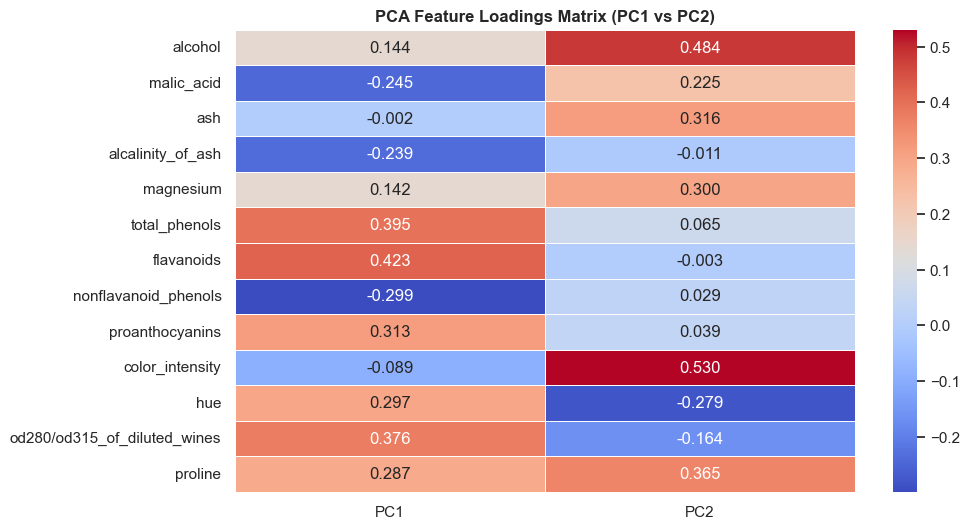

,PC1,PC2
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


In [8]:
# 5. Component Loadings (Feature Contributions to PC1 and PC2)
loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=wine.feature_names)
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('PCA Feature Loadings Matrix (PC1 vs PC2)', fontweight='bold')
plt.show()
display(loadings.sort_values(by='PC1', ascending=False))

### Interpretation of First Two Principal Components (PC1 & PC2)

- **PC1 (36.20% Variance Retained)**: Heavily loaded on phenolic content and flavonoid concentration:
  - **Positive Loadings**: `flavanoids` (+0.423), `total_phenols` (+0.395), `od280/od315_of_diluted_wines` (+0.376).
  - **Negative Loadings**: `nonflavanoid_phenols` (-0.299), `malic_acid` (-0.245), `alcalinity_of_ash` (-0.239).
  - *Domain Significance*: PC1 functions as an axis measuring **overall phenolic quality and wine richness**.

- **PC2 (19.21% Variance Retained)**: Heavily loaded on color intensity and alcohol concentration:
  - **Positive Loadings**: `color_intensity` (+0.530), `alcohol` (+0.484), `proline` (+0.365), `ash` (+0.316).
  - **Negative Loadings**: `hue` (-0.279).
  - *Domain Significance*: PC2 functions as an axis measuring **color concentration and body/strength**.

In [9]:
# 6. Quantitative Comparison: Original vs. Transformed Datasets
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine_scaled, y_wine, test_size=0.20, random_state=42, stratify=y_wine
)

# Benchmark Original (13 Features)
clf_orig = SVC(kernel='rbf', C=1.0, random_state=42)
t0 = time.time()
for _ in range(100): clf_orig.fit(X_train_w, y_train_w)
t_orig = (time.time() - t0) / 100.0
acc_orig = accuracy_score(y_test_w, clf_orig.predict(X_test_w))

# Benchmark PCA 95% Cutoff (10 PCs)
pca_95 = PCA(n_components=min_pcs_95, random_state=42)
X_tr_95 = pca_95.fit_transform(X_train_w)
X_te_95 = pca_95.transform(X_test_w)
clf_95 = SVC(kernel='rbf', C=1.0, random_state=42)
t0 = time.time()
for _ in range(100): clf_95.fit(X_tr_95, y_train_w)
t_95 = (time.time() - t0) / 100.0
acc_95 = accuracy_score(y_test_w, clf_95.predict(X_te_95))

# Benchmark PCA 2D Space (2 PCs)
pca_2 = PCA(n_components=2, random_state=42)
X_tr_2 = pca_2.fit_transform(X_train_w)
X_te_2 = pca_2.transform(X_test_w)
clf_2 = SVC(kernel='rbf', C=1.0, random_state=42)
t0 = time.time()
for _ in range(100): clf_2.fit(X_tr_2, y_train_w)
t_2 = (time.time() - t0) / 100.0
acc_2 = accuracy_score(y_test_w, clf_2.predict(X_te_2))

comp_df = pd.DataFrame([
    {'Representation': 'Original Full Space', 'Features': 13, 'Variance Retained (%)': 100.0, 'Accuracy': acc_orig, 'Fit Time (ms)': t_orig*1000},
    {'Representation': f'PCA 95% Cutoff ({min_pcs_95} PCs)', 'Features': min_pcs_95, 'Variance Retained (%)': cum_variance[min_pcs_95-1]*100, 'Accuracy': acc_95, 'Fit Time (ms)': t_95*1000},
    {'Representation': 'PCA 2D Space (2 PCs)', 'Features': 2, 'Variance Retained (%)': np.sum(evr)*100, 'Accuracy': acc_2, 'Fit Time (ms)': t_2*1000}
])
display(comp_df)

,Representation,Features,Variance Retained (%),Accuracy,Fit Time (ms)
0,Original Full Space,13,100.000000,0.972222,3.079350
1,PCA 95% Cutoff (10 PCs),10,96.169717,0.972222,2.111275
2,PCA 2D Space (2 PCs),2,55.406338,0.944444,1.891243


### Discussion: Advantages, Limitations, and Machine Learning Applications of PCA

#### Advantages
1. **Dimensionality & Multi-Collinearity Reduction**: Removes correlated features and project high-dimensional data onto orthogonal axes.
2. **Data Compression & Efficiency**: Reduces memory footprint and speeds up downstream model training.
3. **Noise Filtering**: Ignores low-variance components which often capture random measurement noise.

#### Limitations
1. **Loss of Feature Interpretability**: Principal components are orthogonal linear combinations of original attributes, making direct domain tracking difficult.
2. **Sensitivity to Feature Scale**: Requires standardization (`StandardScaler`); unscaled variance skews component orientation.
3. **Unsupervised Focus**: PCA maximizes variance regardless of class labels; high-variance directions do not guarantee optimal class separability.

#### Machine Learning Applications
- **Facial Recognition & Computer Vision**: Eigenfaces for compact face representation.
- **Financial & Risk Modeling**: Factor reduction and portfolio risk factor extraction.
- **Pre-processing Pipeline**: Reducing feature dimensions prior to clustering (e.g., K-Means) or classification to mitigate the Curse of Dimensionality.

## Extra Credit: Linear Discriminant Analysis (LDA) vs PCA

Supervised Linear Discriminant Analysis (LDA) maximizes class separability ($S_B / S_W$).


PCA 2D Silhouette Score: 0.5262
LDA 2D Silhouette Score: 0.6632


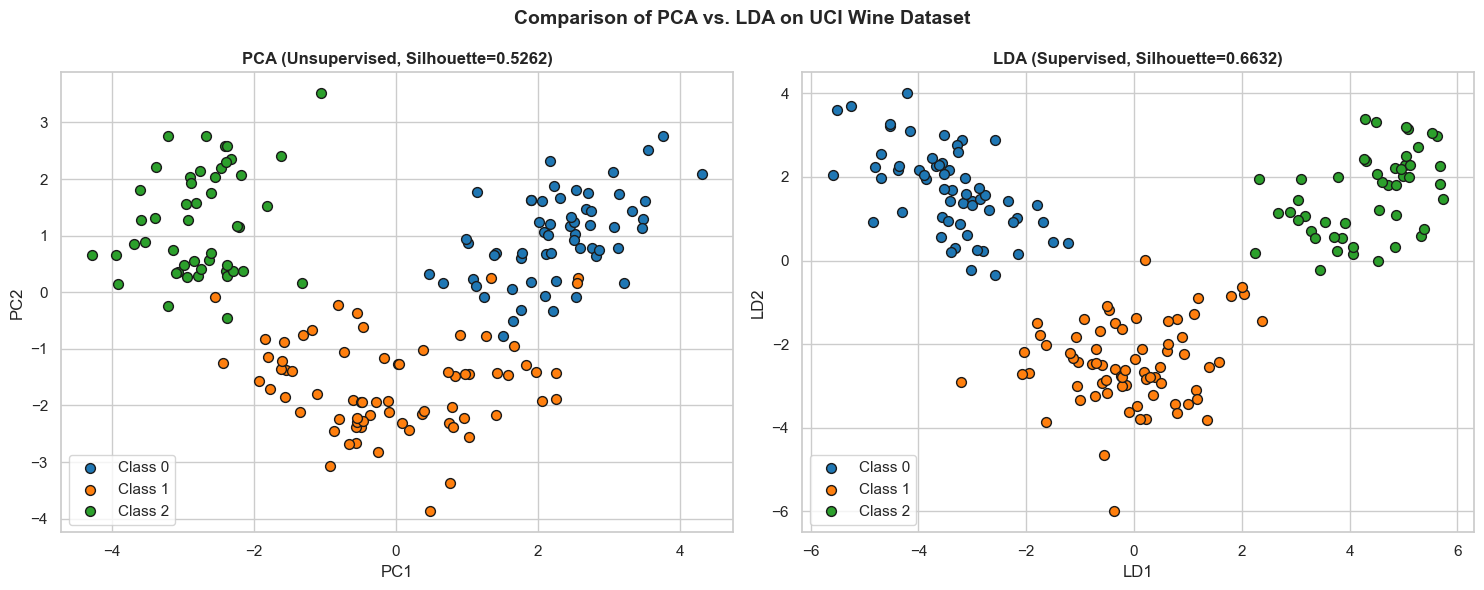

In [10]:
# Apply LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

pca_sil = silhouette_score(X_pca_2d, y_wine)
lda_sil = silhouette_score(X_lda, y_wine)

print(f'PCA 2D Silhouette Score: {pca_sil:.4f}')
print(f'LDA 2D Silhouette Score: {lda_sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for c, name, col in zip(range(3), wine.target_names, colors):
    mask = (y_wine == c)
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=f'Class {c}', color=col, s=50, edgecolors='k')
    ax2.scatter(X_lda[mask, 0], X_lda[mask, 1], label=f'Class {c}', color=col, s=50, edgecolors='k')

ax1.set_title(f'PCA (Unsupervised, Silhouette={pca_sil:.4f})', fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()

ax2.set_title(f'LDA (Supervised, Silhouette={lda_sil:.4f})', fontweight='bold')
ax2.set_xlabel('LD1')
ax2.set_ylabel('LD2')
ax2.legend()

plt.suptitle('Comparison of PCA vs. LDA on UCI Wine Dataset', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()